# Figure 06 -- per-stage time breakdown vs N

Loads `bench/results/scaling/stage_breakdown.json`, produced by `bench/scaling/stage_breakdown.py`. No computation here.

In [1]:
import pathlib, sys
sys.path.insert(0, str(pathlib.Path.cwd().parents[1] if pathlib.Path.cwd().name == "jaccpot_paper" else pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

from examples.jaccpot_paper.common import jsonio, style

style.apply()
FIG_DIR = jsonio.repo_root() / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


attributed fraction of wall clock: 63.75% .. 69.93%


wrote /export/home/tbuck/jaccpot-paper-wt/bench/results/figures/fig06_stage_breakdown.pdf


'/export/home/tbuck/jaccpot-paper-wt/bench/results/figures/fig06_stage_breakdown.pdf'

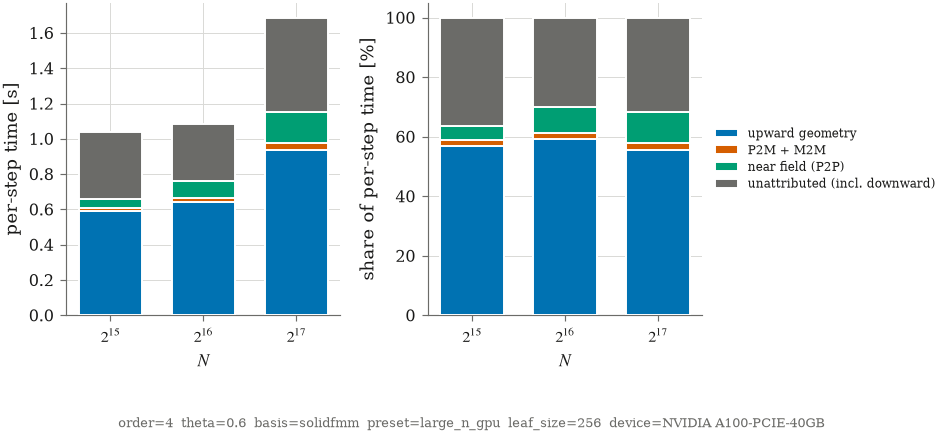

In [2]:
art = jsonio.read_result("scaling/stage_breakdown.json")
cfg, recs = art["config"], art["data"]["records"]
recs = sorted((r for r in recs if "error" not in r), key=lambda r: r["n"])

if not recs:
    raise SystemExit(
        "stage_breakdown.json has no successful rows. This figure needs the "
        "strict refresh path, which is GPU-only -- rerun the bench on a GPU."
    )

# Band list derived from the artifact, not hardcoded. A hardcoded list silently
# dropped `upward_geometry` when the bench script gained it -- 56-59% of the step,
# so the bars stopped summing to the wall clock and the figure understated
# per-step time by a factor of two while looking perfectly plausible. Known keys
# get a display order and a label; anything unrecognised is still plotted, at the
# end, under its raw name.
LABELS = {
    "tree_build": "tree build",
    "upward_geometry": "upward geometry",
    "p2m_m2m": "P2M + M2M",
    "traversal_setup": "traversal setup",
    "m2l": "M2L",
    "l2l": "L2L",
    "nearfield_p2p": "near field (P2P)",
    "other_measured": "other measured",
    "unattributed": "unattributed (incl. downward)",
}
present = {k for r in recs for k in r["stages_s"]}
ORDER = [(k, LABELS.get(k, k)) for k in LABELS if k in present]
ORDER += [(k, k) for k in sorted(present - set(LABELS))]

# The bands must account for the measured wall clock; if they do not, the figure
# is understating per-step cost and should say so rather than be believed.
for r in recs:
    total = sum(r["stages_s"].get(k, 0.0) for k, _ in ORDER)
    if r["per_step_wall_s"] > 0 and abs(total - r["per_step_wall_s"]) / r["per_step_wall_s"] > 0.01:
        print(
            f"WARNING N={r['n']}: bands sum to {total*1e3:.1f} ms but the step took "
            f"{r['per_step_wall_s']*1e3:.1f} ms -- a stage is missing from LABELS"
        )
ns = [r["n"] for r in recs]
x = np.arange(len(ns), dtype=float)

fig, axes = style.figure(width=style.TWO_COL, height=2.9, ncols=2)

# Left: absolute per-step seconds. Right: shares, which is what the figure is for.
for ax, normalise in ((axes[0], False), (axes[1], True)):
    bottom = np.zeros(len(ns))
    for i, (key, label) in enumerate(ORDER):
        vals = np.array([r["stages_s"].get(key, 0.0) for r in recs], dtype=float)
        if normalise:
            totals = np.array([r["per_step_wall_s"] for r in recs], dtype=float)
            vals = np.where(totals > 0, vals / totals * 100.0, 0.0)
        if not vals.any():
            continue
        ax.bar(
            x, vals, bottom=bottom, width=0.68,
            color=(style.INK_MUTED if key in ("unattributed", "other_measured")
                   else style.CATEGORICAL[i % len(style.CATEGORICAL)]),
            # A 2px surface gap between stacked segments keeps adjacent fills
            # from reading as one block.
            edgecolor="white", linewidth=1.0,
            label=label, zorder=3,
        )
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels([f"$2^{{{int(round(np.log2(n)))}}}$" for n in ns])
    ax.set_xlabel("$N$")
    ax.set_ylabel("share of per-step time [%]" if normalise else "per-step time [s]")
    # Linear, not log. A stacked bar on a log axis is a misread waiting to happen:
    # segment *heights* stop being proportional to the values they represent, so a
    # 2% band can look comparable to a 60% one. The absolute panel spans well under
    # a decade here, so linear costs nothing.
    ax.grid(True, axis="y")
    ax.grid(False, axis="x")
    style.finish(ax, legend=normalise, legend_kwargs={"loc": "center left",
                                                     "bbox_to_anchor": (1.01, 0.5),
                                                     "fontsize": 6.4})

frac = [r.get("attributed_fraction") for r in recs if r.get("attributed_fraction")]
if frac:
    print(f"attributed fraction of wall clock: {min(frac):.2%} .. {max(frac):.2%}")
fig.tight_layout()
style.footer(
    fig,
    jsonio.config_caption(cfg, ["order", "theta", "basis", "preset", "leaf_size", "device"]),
)
style.save(fig, FIG_DIR / "fig06_stage_breakdown.pdf")


## Caption

Per-stage contribution to per-step time against $N$, absolute (left) and as a
share (right). Measured on the strict large-$N$ GPU refresh path
(`preset="large_n_gpu"`, radix tree, solidfmm basis), because that is the only
path carrying per-stage instrumentation; it is the production per-step path at
these $N$, but the breakdown should not be read as describing the default
configuration used in figures 1-3. The stage timers do not partition the wall
clock exactly -- local-to-particle evaluation and host-side bookkeeping are not
separately instrumented -- so the remainder is shown explicitly as
*unattributed* rather than rescaled into the measured stages. Values from
`bench/results/scaling/stage_breakdown.json`.
